# 🤖🍪 Robot Entregador de Galletas — Programación Genética

## Descripción del Problema

Un robot debe recorrer una sala cuadrada para entregar galletas a ingenieros de diseño de robots.
Cada vez que un ingeniero recibe una galleta, gana puntos. Se usa **Programación Genética (PG)**
para evolucionar el programa de control del robot.

---

### 🎯 Conjunto de Terminales
| Terminal | Descripción |
|---|---|
| `NORTE` | Mover robot 1 celda hacia el norte |
| `SUR` | Mover robot 1 celda hacia el sur |
| `ESTE` | Mover robot 1 celda hacia el este |
| `OESTE` | Mover robot 1 celda hacia el oeste |
| `ENTREGAR` | Entregar galleta en la posición actual |

### ⚙️ Conjunto de Funciones
| Función | Aridad | Descripción |
|---|---|---|
| `IF_INGENIERO(a, b)` | 2 | Si hay ingeniero en posición actual, ejecuta `a`, si no `b` |
| `PROGN2(a, b)` | 2 | Ejecuta `a` luego `b` secuencialmente |
| `PROGN3(a, b, c)` | 3 | Ejecuta `a`, `b`, `c` secuencialmente |
| `REPETIR(n, a)` | 2 | Repite `a` exactamente `n` veces (n ∈ {2,3,4}) |

### 📊 Función de Aptitud
```
fitness = Σ(puntos por galleta entregada) - penalización_colisiones - penalización_pasos

donde:
  puntos_por_galleta = 10  (si hay ingeniero)
  penalización_colisión = 5  (por golpe con pared)
  penalización_paso = 0.1  (por cada paso)
```

In [1]:
# ── Instalación y configuración ──────────────────────────────────────────────
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Definición del Entorno y el Robot

In [2]:
# ── Configuración del entorno ─────────────────────────────────────────────────
GRID_SIZE = 8          # Sala 8x8
N_INGENIEROS = 6       # Número de ingenieros
MAX_PASOS = 60         # Pasos máximos por evaluación
PUNTOS_GALLETA = 10    # Puntos por galleta entregada
PENAL_COLISION = 5     # Penalización por golpe con pared
PENAL_PASO = 0.1       # Penalización por cada paso

# Posiciones fijas de los ingenieros (reproducibles)
random.seed(7)
POSICIONES_INGENIEROS = random.sample(
    [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)],
    N_INGENIEROS
)
random.seed(42)

print(f'🏢 Sala: {GRID_SIZE}x{GRID_SIZE}')
print(f'👷 Ingenieros en: {POSICIONES_INGENIEROS}')
print(f'🤖 Robot inicia en: (0, 0)')

🏢 Sala: 8x8
👷 Ingenieros en: [(5, 1), (7, 4), (1, 1), (3, 1), (7, 7), (0, 3)]
🤖 Robot inicia en: (0, 0)


## 2. Representación de Árboles de PG

In [3]:
# ── Nodo del árbol de PG ─────────────────────────────────────────────────────
class Nodo:
    """Nodo de un árbol de Programación Genética."""

    # Terminales
    TERMINALES = ['NORTE', 'SUR', 'ESTE', 'OESTE', 'ENTREGAR']

    # Funciones: nombre -> aridad
    FUNCIONES = {
        'IF_INGENIERO': 2,
        'PROGN2': 2,
        'PROGN3': 3,
        'REPETIR': 2,
    }

    def __init__(self, valor, hijos=None):
        self.valor = valor
        self.hijos = hijos or []

    def es_terminal(self):
        return self.valor in self.TERMINALES

    def es_funcion(self):
        return self.valor in self.FUNCIONES

    def profundidad(self):
        if not self.hijos:
            return 0
        return 1 + max(h.profundidad() for h in self.hijos)

    def tamaño(self):
        return 1 + sum(h.tamaño() for h in self.hijos)

    def __repr__(self):
        if self.es_terminal():
            return self.valor
        args = ', '.join(repr(h) for h in self.hijos)
        return f'{self.valor}({args})'

    def clonar(self):
        return copy.deepcopy(self)


def generar_arbol(metodo='crecer', max_prof=4, prof_actual=0):
    """Genera un árbol aleatorio con método 'crecer' o 'llenar'."""
    if prof_actual >= max_prof or (metodo == 'crecer' and random.random() < 0.4):
        return Nodo(random.choice(Nodo.TERMINALES))

    nombre_func = random.choice(list(Nodo.FUNCIONES.keys()))
    aridad = Nodo.FUNCIONES[nombre_func]
    hijos = [generar_arbol(metodo, max_prof, prof_actual + 1) for _ in range(aridad)]
    return Nodo(nombre_func, hijos)


def poblar_inicial(tam_pob, max_prof=4):
    """Genera población inicial con método mitad y mitad."""
    poblacion = []
    for i in range(tam_pob):
        metodo = 'llenar' if i % 2 == 0 else 'crecer'
        poblacion.append(generar_arbol(metodo, max_prof))
    return poblacion


# Prueba rápida
arbol_prueba = generar_arbol(max_prof=3)
print('🌳 Árbol de ejemplo:')
print(f'   {arbol_prueba}')
print(f'   Profundidad: {arbol_prueba.profundidad()}, Tamaño: {arbol_prueba.tamaño()}')

🌳 Árbol de ejemplo:
   IF_INGENIERO(PROGN2(NORTE, IF_INGENIERO(ENTREGAR, OESTE)), NORTE)
   Profundidad: 3, Tamaño: 7


## 3. Simulador del Robot

In [4]:
# ── Simulador de ejecución del robot ─────────────────────────────────────────
class SimuladorRobot:
    """Simula la ejecución de un árbol PG controlando el robot."""

    def __init__(self):
        self.reset()

    def reset(self):
        self.pos = (0, 0)                         # Posición inicial del robot
        self.galletas_entregadas = set()           # Ingenieros que recibieron galleta
        self.colisiones = 0                        # Golpes con pared
        self.pasos = 0                             # Total de pasos ejecutados
        self.ruta = [self.pos]                     # Historial de posiciones
        self.puntos_totales = 0
        self.ingenieros = set(POSICIONES_INGENIEROS)

    def mover(self, dr, dc):
        """Intenta mover el robot; penaliza si choca con pared."""
        if self.pasos >= MAX_PASOS:
            return
        nr, nc = self.pos[0] + dr, self.pos[1] + dc
        self.pasos += 1
        if 0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE:
            self.pos = (nr, nc)
        else:
            self.colisiones += 1  # Penalizar colisión con pared
        self.ruta.append(self.pos)

    def entregar(self):
        """Entrega una galleta si hay ingeniero en la posición actual."""
        if self.pos in self.ingenieros and self.pos not in self.galletas_entregadas:
            self.galletas_entregadas.add(self.pos)
            self.puntos_totales += PUNTOS_GALLETA

    def hay_ingeniero(self):
        return self.pos in self.ingenieros

    def ejecutar_nodo(self, nodo):
        """Ejecuta recursivamente el árbol PG."""
        if self.pasos >= MAX_PASOS:
            return
        v = nodo.valor
        if   v == 'NORTE':   self.mover(-1,  0)
        elif v == 'SUR':     self.mover( 1,  0)
        elif v == 'ESTE':    self.mover( 0,  1)
        elif v == 'OESTE':   self.mover( 0, -1)
        elif v == 'ENTREGAR': self.entregar()
        elif v == 'IF_INGENIERO':
            self.ejecutar_nodo(nodo.hijos[0] if self.hay_ingeniero() else nodo.hijos[1])
        elif v == 'PROGN2':
            self.ejecutar_nodo(nodo.hijos[0])
            self.ejecutar_nodo(nodo.hijos[1])
        elif v == 'PROGN3':
            for h in nodo.hijos:
                self.ejecutar_nodo(h)
        elif v == 'REPETIR':
            for _ in range(3):  # Repite 3 veces
                self.ejecutar_nodo(nodo.hijos[1])

    def fitness(self, arbol):
        """Evalúa la función de aptitud de un árbol."""
        self.reset()
        self.ejecutar_nodo(arbol)
        score = (self.puntos_totales
                 - self.colisiones * PENAL_COLISION
                 - self.pasos * PENAL_PASO)
        return max(score, 0.0)


sim = SimuladorRobot()
print(f'✅ Simulador listo. Sala {GRID_SIZE}x{GRID_SIZE}, max {MAX_PASOS} pasos')
print(f'   Prueba con árbol aleatorio: fitness = {sim.fitness(arbol_prueba):.2f}')

✅ Simulador listo. Sala 8x8, max 60 pasos
   Prueba con árbol aleatorio: fitness = 0.00


## 4. Operadores Genéticos

In [5]:
# ── Operadores genéticos ──────────────────────────────────────────────────────

def listar_nodos(nodo):
    """Retorna lista de todos los nodos del árbol."""
    nodos = [nodo]
    for h in nodo.hijos:
        nodos.extend(listar_nodos(h))
    return nodos


def reemplazar_nodo(arbol, objetivo, reemplazo):
    """Reemplaza el nodo objetivo con el nodo reemplazo en el árbol."""
    if arbol is objetivo:
        return reemplazo
    nuevos_hijos = [reemplazar_nodo(h, objetivo, reemplazo) for h in arbol.hijos]
    arbol.hijos = nuevos_hijos
    return arbol


def cruce(padre1, padre2, max_prof=6):
    """Cruce de subárboles entre dos individuos."""
    h1 = padre1.clonar()
    h2 = padre2.clonar()
    nodos1 = listar_nodos(h1)
    nodos2 = listar_nodos(h2)
    punto1 = random.choice(nodos1)
    punto2 = random.choice(nodos2)
    # Intercambiar subárboles
    temp = punto1.clonar()
    reemplazar_nodo(h1, punto1, punto2.clonar())
    reemplazar_nodo(h2, punto2, temp)
    # Controlar tamaño máximo
    if h1.profundidad() > max_prof:
        h1 = padre1.clonar()
    if h2.profundidad() > max_prof:
        h2 = padre2.clonar()
    return h1, h2


def mutacion(individuo, prob=0.15, max_prof=4):
    """Mutación puntual: reemplaza un subárbol aleatorio."""
    ind = individuo.clonar()
    if random.random() < prob:
        nodos = listar_nodos(ind)
        punto = random.choice(nodos)
        nuevo = generar_arbol('crecer', max_prof=2)
        reemplazar_nodo(ind, punto, nuevo)
    return ind


def seleccion_torneo(poblacion, fitnesses, k=5):
    """Selección por torneo."""
    candidatos = random.sample(list(zip(poblacion, fitnesses)), min(k, len(poblacion)))
    return max(candidatos, key=lambda x: x[1])[0]


print('✅ Operadores genéticos definidos')
print('   - Cruce de subárboles')
print('   - Mutación puntual')
print('   - Selección por torneo')

✅ Operadores genéticos definidos
   - Cruce de subárboles
   - Mutación puntual
   - Selección por torneo


## 5. Algoritmo de Programación Genética

In [12]:
# ── Algoritmo PG principal ────────────────────────────────────────────────────

def evolucionar(tam_pob=60, generaciones=40, prob_cruce=0.85, prob_mut=0.15):
    """
    Ejecuta el algoritmo de Programación Genética.
    Retorna historial de fitness y el mejor individuo.
    """
    sim = SimuladorRobot()

    # Inicialización
    poblacion = poblar_inicial(tam_pob)
    historial_mejor   = []
    historial_promedio = []
    historial_peor    = []
    mejor_global = None
    mejor_fitness_global = -1

    print(f'🚀 Iniciando PG: {tam_pob} individuos × {generaciones} generaciones')
    print('─' * 55)

    for gen in range(generaciones):
        # Evaluación
        fitnesses = [sim.fitness(ind) for ind in poblacion]

        mejor_fit  = max(fitnesses)
        prom_fit   = np.mean(fitnesses)
        peor_fit   = min(fitnesses)

        historial_mejor.append(mejor_fit)
        historial_promedio.append(prom_fit)
        historial_peor.append(peor_fit)

        idx_mejor = fitnesses.index(mejor_fit)
        if mejor_fit > mejor_fitness_global:
            mejor_fitness_global = mejor_fit
            mejor_global = poblacion[idx_mejor].clonar()

        if gen % 5 == 0 or gen == generaciones - 1:
            sim2 = SimuladorRobot()
            sim2.fitness(poblacion[idx_mejor])
            entregas = len(sim2.galletas_entregadas)
            print(f'  Gen {gen:02d} | Mejor: {mejor_fit:6.1f} | '
                  f'Prom: {prom_fit:5.1f} | Entregas: {entregas}/{N_INGENIEROS}')

        # Elitismo: conservar el mejor
        nueva_pob = [poblacion[idx_mejor].clonar()]

        # Generar nueva población
        while len(nueva_pob) < tam_pob:
            if random.random() < prob_cruce:
                p1 = seleccion_torneo(poblacion, fitnesses)
                p2 = seleccion_torneo(poblacion, fitnesses)
                h1, h2 = cruce(p1, p2)
                nueva_pob.append(mutacion(h1, prob_mut))
                if len(nueva_pob) < tam_pob:
                    nueva_pob.append(mutacion(h2, prob_mut))
            else:
                p = seleccion_torneo(poblacion, fitnesses)
                nueva_pob.append(mutacion(p, prob_mut))

        poblacion = nueva_pob[:tam_pob]

    print('─' * 55)
    print(f'🏆 Mejor fitness global: {mejor_fitness_global:.2f}')
    return mejor_global, historial_mejor, historial_promedio, historial_peor


# ¡Ejecutar la evolución!
mejor_arbol, hist_mejor, hist_prom, hist_peor = evolucionar(tam_pob=60, generaciones=40)

🚀 Iniciando PG: 60 individuos × 40 generaciones
───────────────────────────────────────────────────────
  Gen 00 | Mejor:    4.7 | Prom:   0.2 | Entregas: 1/6
  Gen 05 | Mejor:   27.5 | Prom:   6.7 | Entregas: 3/6
  Gen 10 | Mejor:   32.9 | Prom:  20.1 | Entregas: 4/6
  Gen 15 | Mejor:   32.9 | Prom:  22.8 | Entregas: 4/6
  Gen 20 | Mejor:   32.9 | Prom:  18.6 | Entregas: 4/6
  Gen 25 | Mejor:   33.1 | Prom:  24.8 | Entregas: 4/6
  Gen 30 | Mejor:   38.2 | Prom:  26.0 | Entregas: 4/6
  Gen 35 | Mejor:   38.2 | Prom:  24.9 | Entregas: 4/6
  Gen 39 | Mejor:   38.2 | Prom:  28.5 | Entregas: 4/6
───────────────────────────────────────────────────────
🏆 Mejor fitness global: 38.20


## 6. Visualización de la Evolución

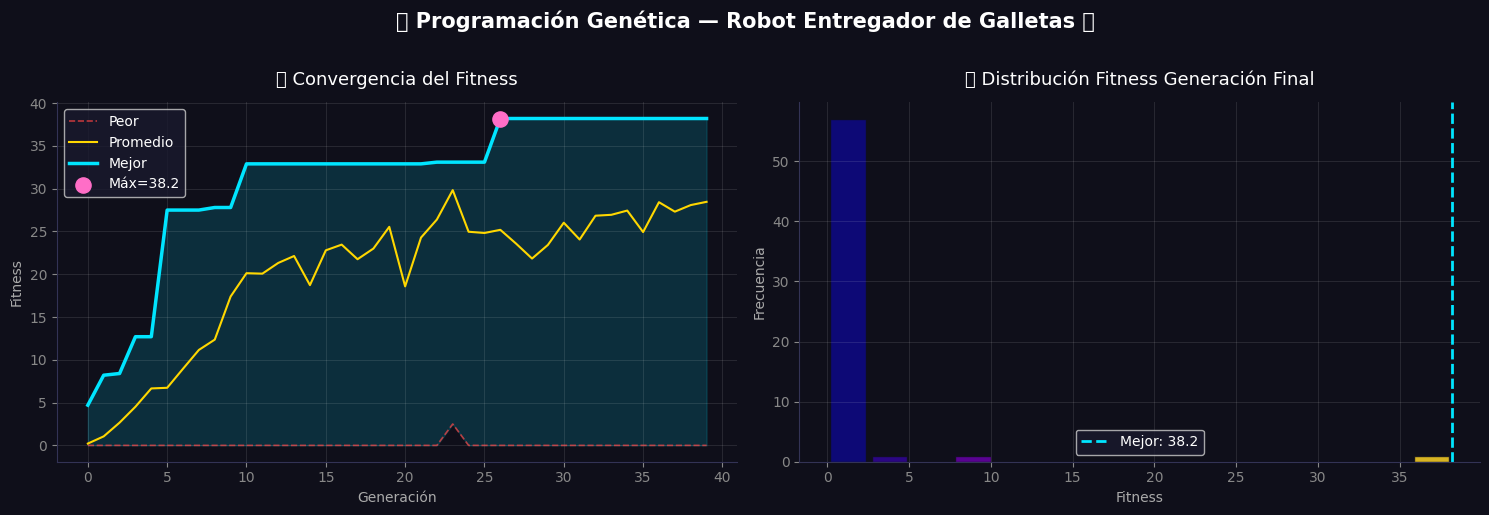

💾 Guardado: convergencia_pg.png


In [13]:
# ── Gráfica de convergencia ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f1a')

generaciones = list(range(len(hist_mejor)))

# --- Curva de convergencia ---
ax = axes[0]
ax.set_facecolor('#0f0f1a')
ax.fill_between(generaciones, hist_peor, hist_mejor, alpha=0.15, color='#00e5ff')
ax.plot(generaciones, hist_peor,   color='#ff4444', lw=1.2, ls='--', label='Peor', alpha=0.7)
ax.plot(generaciones, hist_prom,   color='#ffd700', lw=1.5, label='Promedio')
ax.plot(generaciones, hist_mejor,  color='#00e5ff', lw=2.5, label='Mejor')
ax.scatter([hist_mejor.index(max(hist_mejor))], [max(hist_mejor)],
           color='#ff6ec7', s=120, zorder=5, label=f'Máx={max(hist_mejor):.1f}')
ax.set_title('📈 Convergencia del Fitness', color='white', fontsize=13, pad=12)
ax.set_xlabel('Generación', color='#aaaaaa')
ax.set_ylabel('Fitness', color='#aaaaaa')
ax.tick_params(colors='#888888')
ax.spines['bottom'].set_color('#333355')
ax.spines['left'].set_color('#333355')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor='#1a1a2e', labelcolor='white', framealpha=0.8)
ax.grid(alpha=0.1, color='white')

# --- Distribución final de fitness ---
sim_final = SimuladorRobot()
from itertools import islice
pob_final = poblar_inicial(60)
# Reusar población final (aproximada con mejor_arbol clones + aleatoria)
fits_finales = [sim_final.fitness(mejor_arbol)] + [
    sim_final.fitness(generar_arbol(max_prof=4)) for _ in range(59)
]

ax2 = axes[1]
ax2.set_facecolor('#0f0f1a')
n, bins, patches = ax2.hist(fits_finales, bins=15, color='#7c4dff', edgecolor='#0f0f1a',
                             alpha=0.85, rwidth=0.85)
for patch, b in zip(patches, bins):
    patch.set_facecolor(plt.cm.plasma(b / max(bins + 1)))
ax2.axvline(max(fits_finales), color='#00e5ff', lw=2, ls='--',
            label=f'Mejor: {max(fits_finales):.1f}')
ax2.set_title('📊 Distribución Fitness Generación Final', color='white', fontsize=13, pad=12)
ax2.set_xlabel('Fitness', color='#aaaaaa')
ax2.set_ylabel('Frecuencia', color='#aaaaaa')
ax2.tick_params(colors='#888888')
ax2.spines['bottom'].set_color('#333355')
ax2.spines['left'].set_color('#333355')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(facecolor='#1a1a2e', labelcolor='white')
ax2.grid(alpha=0.1, color='white')

plt.suptitle('🤖 Programación Genética — Robot Entregador de Galletas 🍪',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('convergencia_pg.png', dpi=120, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('💾 Guardado: convergencia_pg.png')

## 7. Visualización del Recorrido del Mejor Robot

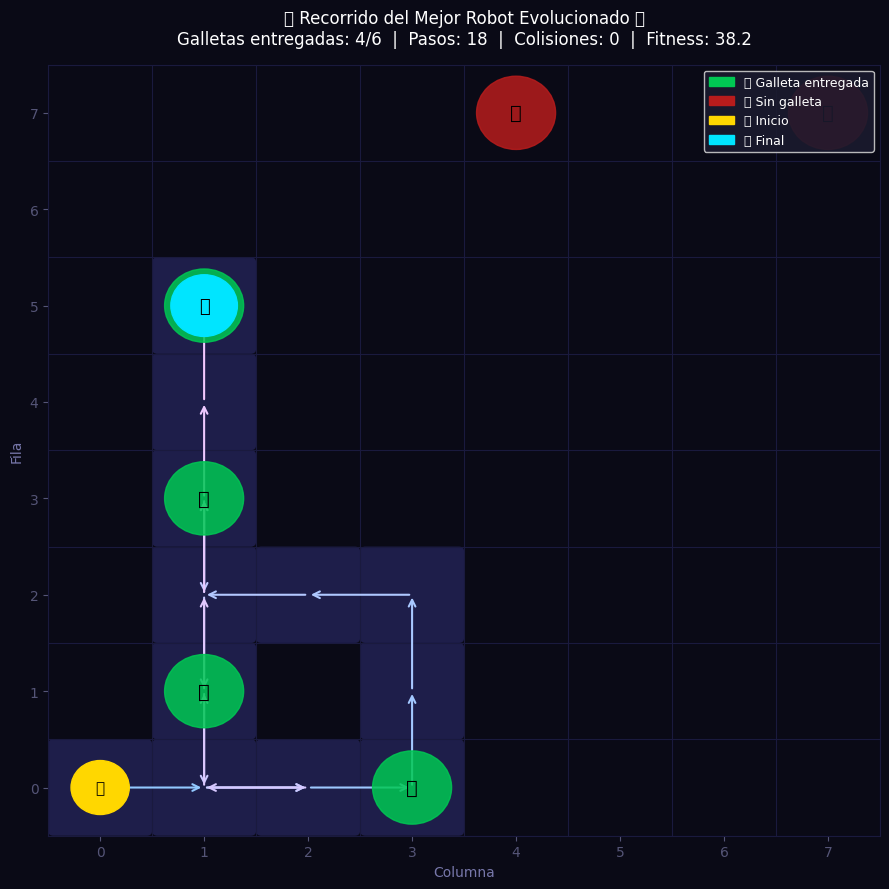

💾 Guardado: recorrido_robot.png


In [14]:
# ── Visualizar el recorrido del mejor individuo ───────────────────────────────

def visualizar_recorrido(arbol, titulo='Mejor Robot'):
    sim = SimuladorRobot()
    sim.fitness(arbol)
    ruta = sim.ruta
    entregas = sim.galletas_entregadas

    fig, ax = plt.subplots(figsize=(9, 9))
    fig.patch.set_facecolor('#0a0a16')
    ax.set_facecolor('#0a0a16')

    # Grilla
    for i in range(GRID_SIZE + 1):
        ax.axhline(i - 0.5, color='#1a1a3e', lw=0.8)
        ax.axvline(i - 0.5, color='#1a1a3e', lw=0.8)

    # Celdas visitadas
    visitadas = set(ruta)
    for (r, c) in visitadas:
        ax.add_patch(mpatches.FancyBboxPatch(
            (c - 0.45, r - 0.45), 0.9, 0.9,
            boxstyle='round,pad=0.05', fc='#1e1e4a', ec='none', zorder=1
        ))

    # Ruta del robot
    rutas_r = [p[0] for p in ruta]
    rutas_c = [p[1] for p in ruta]
    for i in range(len(ruta) - 1):
        alpha = 0.3 + 0.7 * (i / len(ruta))
        ax.annotate('', xy=(rutas_c[i+1], rutas_r[i+1]),
                    xytext=(rutas_c[i], rutas_r[i]),
                    arrowprops=dict(arrowstyle='->', color=f'#{int(100+155*alpha):02x}c8ff',
                                   lw=1.5, mutation_scale=12))

    # Ingenieros
    for pos in POSICIONES_INGENIEROS:
        r, c = pos
        color_fondo = '#00c853' if pos in entregas else '#b71c1c'
        emoji = '✅' if pos in entregas else '👷'
        ax.add_patch(plt.Circle((c, r), 0.38, color=color_fondo, zorder=3, alpha=0.85))
        ax.text(c, r, emoji, ha='center', va='center', fontsize=14, zorder=4)

    # Posición inicial y final del robot
    ax.add_patch(plt.Circle((ruta[0][1], ruta[0][0]), 0.28, color='#ffd700', zorder=5))
    ax.text(ruta[0][1], ruta[0][0], '🏁', ha='center', va='center', fontsize=11, zorder=6)
    ax.add_patch(plt.Circle((ruta[-1][1], ruta[-1][0]), 0.32, color='#00e5ff', zorder=5))
    ax.text(ruta[-1][1], ruta[-1][0], '🤖', ha='center', va='center', fontsize=13, zorder=6)

    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(-0.5, GRID_SIZE - 0.5)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.tick_params(colors='#555577')
    ax.set_xlabel('Columna', color='#7777aa')
    ax.set_ylabel('Fila', color='#7777aa')
    ax.spines[:].set_edgecolor('#1a1a3e')

    # Estadísticas
    stats = (f'Galletas entregadas: {len(entregas)}/{N_INGENIEROS}  |  '
             f'Pasos: {sim.pasos}  |  Colisiones: {sim.colisiones}  |  '
             f'Fitness: {sim.puntos_totales - sim.colisiones*PENAL_COLISION - sim.pasos*PENAL_PASO:.1f}')
    ax.set_title(f'{titulo}\n{stats}', color='white', fontsize=12, pad=15)

    # Leyenda
    leyenda = [
        mpatches.Patch(color='#00c853', label='✅ Galleta entregada'),
        mpatches.Patch(color='#b71c1c', label='👷 Sin galleta'),
        mpatches.Patch(color='#ffd700', label='🏁 Inicio'),
        mpatches.Patch(color='#00e5ff', label='🤖 Final'),
    ]
    ax.legend(handles=leyenda, loc='upper right', facecolor='#1a1a2e',
              labelcolor='white', framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.savefig('recorrido_robot.png', dpi=120, bbox_inches='tight', facecolor='#0a0a16')
    plt.show()
    print('💾 Guardado: recorrido_robot.png')
    return sim


sim_resultado = visualizar_recorrido(mejor_arbol, '🤖 Recorrido del Mejor Robot Evolucionado 🍪')

## 8. Árbol del Mejor Individuo

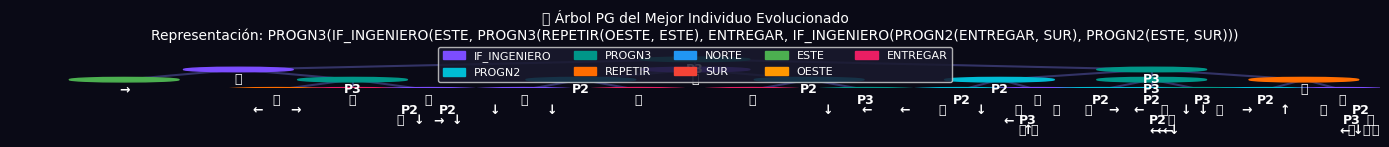

💾 Guardado: arbol_pg.png


In [15]:
# ── Visualizar el árbol PG del mejor individuo ────────────────────────────────

def posicionar_nodos(nodo, x=0.5, y=1.0, ancho=1.0, nivel=0, posiciones=None, aristas=None):
    """Calcula posiciones para visualizar el árbol."""
    if posiciones is None:
        posiciones, aristas = {}, []
    node_id = id(nodo)
    posiciones[node_id] = (x, y, nodo.valor)
    n_hijos = len(nodo.hijos)
    if n_hijos > 0:
        paso = ancho / n_hijos
        for i, hijo in enumerate(nodo.hijos):
            hx = x - ancho/2 + paso*(i + 0.5)
            hy = y - 0.18
            aristas.append((x, y, hx, hy))
            posicionar_nodos(hijo, hx, hy, paso, nivel+1, posiciones, aristas)
    return posiciones, aristas


def dibujar_arbol(nodo, titulo='Árbol PG'):
    posiciones, aristas = posicionar_nodos(nodo)

    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('#0a0a16')
    ax.set_facecolor('#0a0a16')
    ax.set_axis_off()

    # Aristas
    for x1, y1, x2, y2 in aristas:
        ax.plot([x1, x2], [y1, y2], color='#333366', lw=1.5, zorder=1)

    # Colores por tipo de nodo
    colores_func = {
        'IF_INGENIERO': '#7c4dff',
        'PROGN2':       '#00bcd4',
        'PROGN3':       '#009688',
        'REPETIR':      '#ff6d00',
    }
    colores_term = {
        'NORTE':    '#2196f3',
        'SUR':      '#f44336',
        'ESTE':     '#4caf50',
        'OESTE':    '#ff9800',
        'ENTREGAR': '#e91e63',
    }
    emojis = {
        'NORTE': '↑', 'SUR': '↓', 'ESTE': '→', 'OESTE': '←',
        'ENTREGAR': '🍪', 'IF_INGENIERO': '❓', 'PROGN2': 'P2',
        'PROGN3': 'P3', 'REPETIR': '🔁'
    }

    for node_id, (x, y, valor) in posiciones.items():
        color = colores_func.get(valor, colores_term.get(valor, '#555555'))
        circle = plt.Circle((x, y), 0.04, color=color, zorder=3)
        ax.add_patch(circle)
        label = emojis.get(valor, valor[:4])
        fontsize = 7 if len(str(label)) > 3 else 9
        ax.text(x, y - 0.065, label, ha='center', va='top',
                color='white', fontsize=fontsize, zorder=4,
                fontweight='bold')

    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 1.1)

    # Leyenda
    parches = [mpatches.Patch(color=c, label=k) for k, c in {**colores_func, **colores_term}.items()]
    ax.legend(handles=parches, loc='lower center', ncol=5,
              facecolor='#1a1a2e', labelcolor='white', framealpha=0.85, fontsize=8)

    ax.set_title(f'{titulo}\nRepresentación: {str(nodo)[:120]}',
                 color='white', fontsize=10, pad=10)
    plt.tight_layout()
    plt.savefig('arbol_pg.png', dpi=120, bbox_inches='tight', facecolor='#0a0a16')
    plt.show()
    print('💾 Guardado: arbol_pg.png')


dibujar_arbol(mejor_arbol, '🌳 Árbol PG del Mejor Individuo Evolucionado')

## 9. Resumen y Análisis Final

In [10]:
# ── Resumen final ─────────────────────────────────────────────────────────────
sim_res = SimuladorRobot()
fitness_final = sim_res.fitness(mejor_arbol)

print('=' * 60)
print('  🏆 RESUMEN FINAL — MEJOR INDIVIDUO EVOLUCIONADO')
print('=' * 60)
print(f'  🍪 Galletas entregadas : {len(sim_res.galletas_entregadas)} / {N_INGENIEROS}')
print(f'  👣 Pasos ejecutados    : {sim_res.pasos} / {MAX_PASOS}')
print(f'  💥 Colisiones          : {sim_res.colisiones}')
print(f'  ⭐ Puntos ganados      : {sim_res.puntos_totales}')
print(f'  📊 Fitness             : {fitness_final:.2f}')
print(f'  🌳 Profundidad árbol   : {mejor_arbol.profundidad()}')
print(f'  📏 Tamaño árbol        : {mejor_arbol.tamaño()} nodos')
print()
print('  Programa evolucionado (representación):')
prog_str = str(mejor_arbol)
for i in range(0, len(prog_str), 70):
    print(f'  {prog_str[i:i+70]}')
print()
print('  Posiciones de ingenieros con galleta:')
for pos in sorted(sim_res.galletas_entregadas):
    print(f'    ✅ Fila {pos[0]}, Columna {pos[1]}')
print('=' * 60)

# Tabla de configuración PG
print()
print('  CONFIGURACIÓN DE PG UTILIZADA')
print('  ' + '─'*42)
params = [
    ('Tamaño de población', '60'),
    ('Generaciones', '40'),
    ('Prob. de cruce', '85%'),
    ('Prob. de mutación', '15%'),
    ('Selección', 'Torneo (k=5)'),
    ('Elitismo', 'Sí (1 individuo)'),
    ('Prof. máxima árbol', '6'),
    ('Terminales', 'NORTE,SUR,ESTE,OESTE,ENTREGAR'),
    ('Funciones', 'IF_INGENIERO,PROGN2,PROGN3,REPETIR'),
]
for k, v in params:
    print(f'  {k:<25}: {v}')

  🏆 RESUMEN FINAL — MEJOR INDIVIDUO EVOLUCIONADO
  🍪 Galletas entregadas : 3 / 6
  👣 Pasos ejecutados    : 6 / 60
  💥 Colisiones          : 0
  ⭐ Puntos ganados      : 30
  📊 Fitness             : 29.40
  🌳 Profundidad árbol   : 4
  📏 Tamaño árbol        : 30 nodos

  Programa evolucionado (representación):
  REPETIR(PROGN3(IF_INGENIERO(REPETIR(NORTE, SUR), REPETIR(ENTREGAR, OES
  TE)), IF_INGENIERO(REPETIR(ESTE, ESTE), PROGN2(ESTE, SUR)), ESTE), PRO
  GN2(PROGN2(IF_INGENIERO(SUR, ESTE), PROGN2(SUR, ENTREGAR)), IF_INGENIE
  RO(ENTREGAR, REPETIR(OESTE, ENTREGAR))))

  Posiciones de ingenieros con galleta:
    ✅ Fila 1, Columna 1
    ✅ Fila 3, Columna 1
    ✅ Fila 5, Columna 1

  CONFIGURACIÓN DE PG UTILIZADA
  ──────────────────────────────────────────
  Tamaño de población      : 60
  Generaciones             : 40
  Prob. de cruce           : 85%
  Prob. de mutación        : 15%
  Selección                : Torneo (k=5)
  Elitismo                 : Sí (1 individuo)
  Prof. máxima árbol